In [ ]:
using Pkg
Pkg.add(["XLSX", "DataFrames", "Statistics", "Plots", "StatsPlots"])

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Distances ───────── v0.10.12
   Installed CodecInflate64 ──── v0.1.3
   Installed InputBuffers ────── v1.1.1
   Installed ArgCheck ────────── v2.5.0
   Installed StatsPlots ──────── v0.15.8
   Installed ZipArchives ─────── v2.6.0
   Installed NearestNeighbors ── v0.4.27
   Installed Clustering ──────── v0.15.8
   Installed Arpack_jll ──────── v3.5.2+0
   Installed TableOperations ─── v1.2.0
   Installed Arpack ──────────── v0.5.4
   Installed XML ─────────────── v0.3.8
   Installed Widgets ─────────── v0.6.7
   Installed XLSX ────────────── v0.11.4
   Installed MultivariateStats ─ v0.10.4
  Installing 1 artifacts
   Installed artifact Arpack                   138.3 KiB
    Updating `~/.julia/environments/v1.12/Project.toml`
  [10745b16] + Statistics v1.11.1
  [f3b207a7] + StatsPlots v0.15.8
  [fdbf4ff8] + XLSX v0.11.4
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [dce0

In [ ]:
using XLSX
using DataFrames
using Statistics
using Plots
using StatsPlots
using Printf

In [ ]:
# --- 1. CARGA DE DATOS DESDE EXCEL ---
file_path = "ComercioInternacional.xlsx"

"ComercioInternacional.xlsx"

In [ ]:
# 2. Carga de datos
xf = XLSX.readxlsx(file_path)
nombre_hoja = XLSX.sheetnames(xf)[1]
data_table = XLSX.readtable(file_path, nombre_hoja; infer_eltypes=true)
df = DataFrame(data_table)

Row,Rkn,Partida,Descripcion,Pais,Año,Mes,Peso Neto(t),Peso Bruto (t),Valor FOB (t)
,Int64,String,String,String,Int64,String,Float64,Float64,Float64
1,2,0806100000,UVAS FRESCAS,ESTADOS UNIDOS,2026,01,1.13181e5,1.31779e5,3.05023e5
2,3,0810400000,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",ESTADOS UNIDOS,2026,01,17223.0,21028.6,1.08954e5
3,4,0804502000,"MANGOS Y MANGOSTANES, FRESCOS O SECOS",ESTADOS UNIDOS,2026,01,33940.8,37758.7,50532.2
4,5,0806100000,UVAS FRESCAS,MEXICO,2026,01,15595.3,18070.5,48686.8
5,6,0806100000,UVAS FRESCAS,HOLANDA,2026,01,12175.5,14272.0,34111.7
6,7,0810400000,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",HOLANDA,2026,01,5314.76,6548.04,33164.5
7,8,0804502000,"MANGOS Y MANGOSTANES, FRESCOS O SECOS",HOLANDA,2026,01,22113.4,24776.4,29816.7
8,9,0806100000,UVAS FRESCAS,TAIWAN (FORMOSA),2026,01,4068.86,4752.39,17303.5
9,10,0806100000,UVAS FRESCAS,ESPAÑA,2026,01,6185.42,7147.73,16553.1


In [ ]:
# 3. Limpieza: Omitir fila de TOTAL (fila 1) y normalizar nombres
df_clean = df[2:end, :]

# Identificación de columnas (usamos índices para evitar errores de nombres con paréntesis)
# 3: Descripcion, 4: Pais, 9: Valor FOB
df_analisis = DataFrame(
    Producto = df_clean[:, 3],
    Pais = df_clean[:, 4],
    ValorFOB = Float64.(coalesce.(df_clean[:, 9], 0.0))
)

Row,Producto,Pais,ValorFOB
,String,String,Float64
1,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",ESTADOS UNIDOS,1.08954e5
2,"MANGOS Y MANGOSTANES, FRESCOS O SECOS",ESTADOS UNIDOS,50532.2
3,UVAS FRESCAS,MEXICO,48686.8
4,UVAS FRESCAS,HOLANDA,34111.7
5,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",HOLANDA,33164.5
6,"MANGOS Y MANGOSTANES, FRESCOS O SECOS",HOLANDA,29816.7
7,UVAS FRESCAS,TAIWAN (FORMOSA),17303.5
8,UVAS FRESCAS,ESPAÑA,16553.1
9,UVAS FRESCAS,CHINA,14883.6


In [ ]:
# 4. Agrupación por Producto y País
# Agrupamos por Producto y País para obtener los valores FOB más altos
agrupado = combine(groupby(df_analisis, [:Producto, :Pais]), :ValorFOB => sum => :TotalFOB)
sort!(agrupado, :TotalFOB, rev=true)

top_5 = first(agrupado, 5)



Row,Producto,Pais,TotalFOB
,String,String,Float64
1,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",ESTADOS UNIDOS,1.08954e5
2,"MANGOS Y MANGOSTANES, FRESCOS O SECOS",ESTADOS UNIDOS,50532.2
3,UVAS FRESCAS,MEXICO,48686.8
4,UVAS FRESCAS,HOLANDA,34111.7
5,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",HOLANDA,33164.5


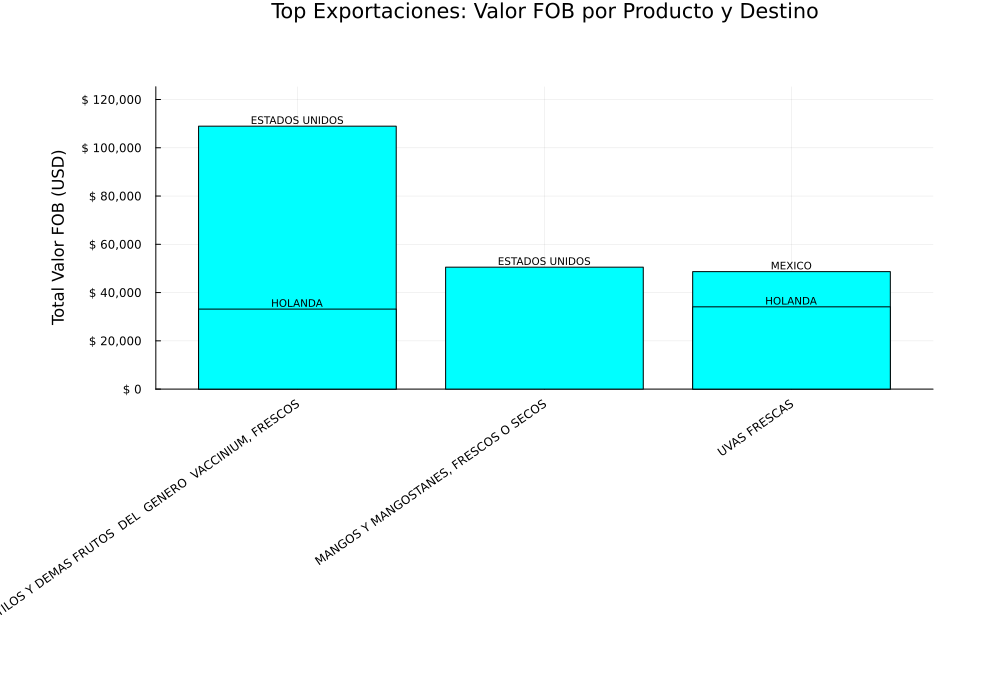

In [ ]:
# 5. Configuración del Gráfico
    gr(size=(1000, 700))

    # Etiquetas de países con una pequeña rotación para evitar solapamientos
    etiquetas_pais = text.(top_5.Pais, :bottom, 7, :black)

    # Formateador para el eje Y (Precio visualmente natural con separador de miles)
    # Esto transforma 300000.0 en "300,000"
    fmt_moneda(y) = @sprintf("%.0f", y) |> x -> replace(x, r"(?<=\d)(?=(\d{3})+(?!\d))" => ",")

    p = bar(
        top_5.Producto,
        top_5.TotalFOB,
        title = "Top Exportaciones: Valor FOB por Producto y Destino",
        xlabel = "Producto",
        ylabel = "Total Valor FOB (USD)",
        xrotation = 35,
        color = :cyan,
        legend = false,
        yformatter = y -> "\$ " * fmt_moneda(y), # Agrega el símbolo $ y comas
        series_annotations = etiquetas_pais,
        ylims = (0, maximum(top_5.TotalFOB) * 1.15), # Espacio extra para que el texto no se corte
        margin = 15Plots.mm
    )
display(p)

In [ ]:
# 6. Mostrar tabla de resultados en consola
    println("\n--- TOP 5 EXPORTACIONES (PRODUCTO - PAÍS) ---")
    println(first(top_5[:, [:Producto, :Pais, :TotalFOB]], 5))


--- TOP 5 EXPORTACIONES (PRODUCTO - PAÍS) ---
5×3 DataFrame
 Row │ Producto                           Pais            TotalFOB      
     │ String                             String          Float64       
─────┼──────────────────────────────────────────────────────────────────
   1 │ ARANDANOS  ROJOS,  MIRTILOS Y DE…  ESTADOS UNIDOS      1.08954e5
   2 │ MANGOS Y MANGOSTANES, FRESCOS O …  ESTADOS UNIDOS  50532.2
   3 │ UVAS FRESCAS                       MEXICO          48686.8
   4 │ UVAS FRESCAS                       HOLANDA         34111.7
   5 │ ARANDANOS  ROJOS,  MIRTILOS Y DE…  HOLANDA         33164.5
